# Model Prediction and Serving: Companion Notebook

> Companion for `src/my_mlops_project/pipelines/model_predict/` and the FastAPI
> app in `serving/`.

**Purpose:** batch-score the test set, log per-prediction SHAP, and demonstrate
the **online FastAPI service** that serves the champion.

**Inputs:** `X_test`, `champion_model`.
**Outputs:** `predictions.parquet`, `decision_log.json`, `shap_predictions.parquet`;
plus the FastAPI app + Dockerfile under `serving/`.

## Table of Contents
1. [Setup](#1-setup)
2. [Batch predictions](#2-batch-predictions)
3. [Score distribution](#3-score-distribution)
4. [Per-prediction SHAP](#4-per-prediction-shap)
5. [The FastAPI service (live demo)](#5-the-fastapi-service-live-demo)
6. [Containerisation](#6-containerisation)
7. [Notes for the report](#7-notes-for-the-report)

## 1. Setup

In [1]:
import os, sys, json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)                  # so the registry (sqlite:///mlflow.db) resolves
sys.path.insert(0, str(PROJECT_ROOT / "serving"))
DATA = PROJECT_ROOT / "data"
print("working dir:", Path.cwd().name)

working dir: Project


## 2. Batch predictions

The `model_predict` pipeline scored the held-out test set with the champion.

In [2]:
predictions = pd.read_parquet(DATA / "07_model_output" / "predictions.parquet")
decision_log = json.load(open(DATA / "08_reporting" / "decision_log.json"))
print(json.dumps(decision_log, indent=2))
print((predictions.head()).to_string())

{
  "n_scored": 5993,
  "threshold": 0.5,
  "n_predicted_default": 707,
  "predicted_default_rate": 0.11797096612714834,
  "proba_mean": 0.22058710774393506,
  "proba_median": 0.13920982064468806,
  "proba_p95": 0.7068587392088292
}
       default_proba  prediction
8681        0.106552           0
24179       0.093219           0
27755       0.124461           0
14938       0.188410           0
1486        0.039912           0


## 3. Score distribution

The distribution of predicted default probabilities. Useful for choosing/monitoring the decision threshold.

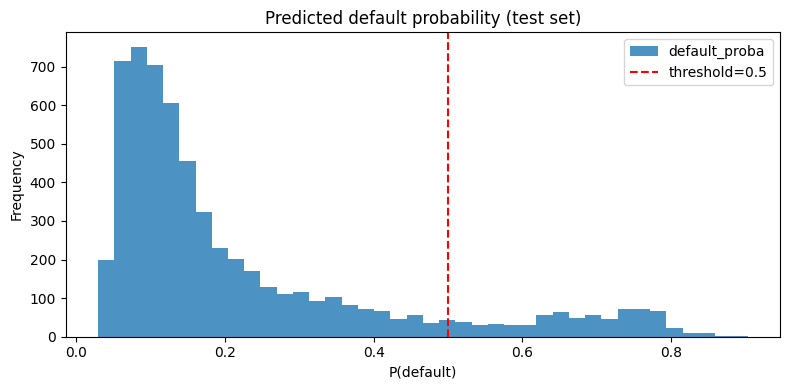

In [3]:
ax = predictions["default_proba"].plot(kind="hist", bins=40, figsize=(8, 4), alpha=0.8)
ax.axvline(decision_log["threshold"], color="red", linestyle="--", label=f"threshold={decision_log['threshold']}")
ax.set_title("Predicted default probability (test set)")
ax.set_xlabel("P(default)")
ax.legend()
plt.tight_layout()
plt.savefig(DATA / "08_reporting" / "score_distribution.png", dpi=120)
plt.show()

## 4. Per-prediction SHAP

Every production score can be explained. Here are the top drivers for one customer. The explanation-level monitoring signal (week 6).

In [4]:
shap_preds = pd.read_parquet(DATA / "08_reporting" / "shap_predictions.parquet")
one = shap_preds.iloc[0]
top = one.reindex(one.abs().sort_values(ascending=False).index).head(8)
print("Top SHAP drivers for the first scored customer:")
print(top.round(4).to_string())

Top SHAP drivers for the first scored customer:
BILL_AMT2        0.4847
PAY_AMT2        -0.3221
max_bill        -0.2255
PAY_0           -0.2089
BILL_AMT4        0.1810
PAY_AMT1         0.1282
pay_delay_max   -0.1208
BILL_AMT3        0.1165


## 5. The FastAPI service (live demo)

The online counterpart of batch scoring. We import the app and call it in-process
with FastAPI's `TestClient`. No server needed. The `lifespan` loads the champion
from the MLflow registry at startup.

In [5]:
from fastapi.testclient import TestClient
from app.main import app

X_test = pd.read_parquet(DATA / "05_model_input" / "X_test.parquet")
sample_features = X_test.iloc[0].to_dict()

with TestClient(app) as client:
    print("health:", client.get("/health").json())
    print("ready :", client.get("/ready").json())
    resp = client.post("/predict", json={"features": sample_features})
    print("predict:", resp.status_code, resp.json())

health: {'status': 'ok'}
ready : {'ready': True}
predict: 200 {'default_probability': 0.1066, 'prediction': 0, 'threshold': 0.5}


## 6. Containerisation

The service ships as a Docker image (build from the project root, tag by git SHA,
never `:latest`):

```bash
docker build -f serving/Dockerfile -t credit-default-api:dev .
docker run -p 8000:8000 credit-default-api:dev
```

See [`../serving/README.md`](../serving/README.md). One process per container;
scale horizontally with replicas behind a load balancer / Kubernetes.

## 7. Notes for the report

> For [`../report/REPORT_OUTLINE.md`](../report/REPORT_OUTLINE.md) section 4 (serving) and section 5 (production).

- **Batch + online inference**. The Kedro `model_predict` node scores in bulk;
  the FastAPI app serves single requests. Both use the same registered champion.
- **Serving pattern**. The API loads the champion from the **MLflow registry at
  startup** (`app/loader.py`), so the image stays model-agnostic; promoting a new
  champion needs no rebuild.
- **Containerised**, `serving/Dockerfile` (non-root, git-SHA tag, one process per
  container). Scaling/K8s/load-balancing discussed in the production section.
- **Explainability in production**. Per-prediction SHAP is logged so every score
  is auditable (and shifting attributions flag drift).